# Zadanie 4: obliczenia ewolucyjne

Termin realizacji: 4 maja 2026

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Zmodyfikuj przykład "iterative method" z notatnika `tsp_lazy_constraints.ipynb` tak, aby rozwiązywał [problem podróżującego konsumenta](https://en.wikipedia.org/wiki/Traveling_purchaser_problem). Przykładowe problemy generuje poniższa funkcja `generate_random_tpp`. Przyjmij, że wszystkie miasta muszą być odwiedzone niezależnie od tego czy dokonany tam będzie zakup czy też nie. W rozwiązaniu wypisz w którym mieście kupione będą poszczególne przedmioty oraz narysuj trasę.
2. Zmodyfikuj analogicznie kod z notatnika `tsp-genetic.ipynb` tak aby rozwiązywał ten sam problem. Porównaj wydajność (czas obliczeń i wartość funkcji kosztu) dla dziewięciu losowych problemów, po trzy dla rozmiarów (n=50, k=20), (n=50, k=50) oraz (n=100, k=100). Dobierz parametry algorytmu genetycznego tak, aby czas działania nie przekraczał w żadnym przypadku minuty.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Dodaj do problemu wagę przedmiotów, powiększającą koszt rozwiązania o długość trasy od miejsca zakupu do końca trasy pomnożoną przez wagę przedmiotu i stały współczynnik dobrany tak, aby dla przedmiotu średniej wagi jego transport między najbardziej odległymi miastami (w linii prostej) wynosił około 1% ceny. Nie dodawaj tego składnika do funkcji kosztu zaimplementowanej w JuMP, ale uwzględnij go w algorytmie genetycznym. Porównaj jakość rozwiązań uzyskanych przez oba algorytmy z uwzględnieniem wagi i bez.
3. Zaimplementuj dodatkowo [krzyżowanie PMX](https://en.wikipedia.org/wiki/Crossover_(genetic_algorithm)#Partially_mapped_crossover_(PMX)) i porównaj wydajność z tym opartym o inwersję permutacji.

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Zmodyfikuj problem tak, aby konsument nie musiał odwiedzać miast w których niczego nie kupuje.
3. Dodaj dodatkowo do porównania zmodyfikowany dla problemu podróżującego konsumenta przykład "lazy constraints" z notatnika `tsp_lazy_constraints.ipynb`. Dane do problemu powinny być generowane tak, aby konsument w zwracanym rozwiązaniu odwiedzał przynajmniej 3 miasta i omijał przynajmniej 2.


In [1]:
import Pkg; Pkg.add("JuMP")

using JuMP
import GLPK
import Random
import Plots

function generate_random_tpp(n, k; random_seed = 1)
    rng = Random.MersenneTwister(random_seed)
    # distance matrix
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    d = [sqrt((X[i] - X[j])^2 + (Y[i] - Y[j])^2) for i in 1:n, j in 1:n]

    cost_item_city = 50 .+ 100 .* rand(rng, k, n) # cost_item_city[num_item, num_city]

    return X, Y, d, cost_item_city
end

n = 100
k = 100
X, Y, d, cost_item_city = generate_random_tpp(n, k)

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


([9.913970137863682, 70.19797138879542, 50.3261785841856, 87.58412053070398, 95.34654118744876, 50.7810571056071, 78.97511635624403, 7.125413261100788, 13.837807897217225, 39.31891799217675  …  84.87369607977678, 61.680928138712, 5.665730912653899, 15.622563304879634, 36.90767228785501, 70.07597765092129, 79.43901471209098, 46.482254570311675, 68.59072330642508, 86.69884288310024], [96.78179466896867, 56.23453714649542, 67.44638756669107, 7.1115103002265645, 92.78034391338332, 34.57366887562756, 76.53412034001651, 33.078576899782796, 62.27235533684083, 31.31072581673351  …  1.4463814325218927, 42.253985947804495, 53.81635009641501, 76.50117040708963, 27.74238915740479, 60.20183753580153, 19.81346291572821, 90.60507365183767, 31.10234142135033, 21.085230265206945], [0.0 72.65150307747324 … 88.07242440917794 107.82340444001487; 72.65150307747324 0.0 … 25.183536454701592 38.829789264256306; … ; 88.07242440917794 25.183536454701592 … 0.0 20.69411777577625; 107.82340444001487 38.82978926425

# Na 3.0

## Iterative method dla problemu podróżującego konsumenta (JuMP)

Zmodyfikowano model iteracyjny dodając zmienne `y[item, city]`, decydujące w którym mieście zostanie kupiony dany przedmiot. Funkcja celu sumuje długość trasy i koszty zakupu. Trasa jest budowana tak, żeby odwiedzić wszystkie miasta (ograniczenie `sum(x[i,:]) == 2`), a podtrasy są eliminowane iteracyjnie.

In [2]:
function selected_edges(x::AbstractMatrix, n)
    return Tuple{Int,Int}[(i, j) for i in 1:n, j in 1:n if x[i, j] > 0.5]
end

function subtour(edges::Vector{Tuple{Int,Int}}, n)
    shortest_subtour, unvisited = collect(1:n), Set(collect(1:n))
    while !isempty(unvisited)
        this_cycle, neighbors = Int[], unvisited
        while !isempty(neighbors)
            current = pop!(neighbors)
            push!(this_cycle, current)
            if length(this_cycle) > 1
                pop!(unvisited, current)
            end
            neighbors = [j for (i, j) in edges if i == current && j in unvisited]
        end
        if length(this_cycle) < length(shortest_subtour)
            shortest_subtour = this_cycle
        end
    end
    return shortest_subtour
end

subtour(x::AbstractMatrix{Float64}) = subtour(selected_edges(x, size(x, 1)), size(x, 1))
subtour(x::AbstractMatrix{VariableRef}) = subtour(JuMP.value.(x))

function build_tpp_model(d, cost_item_city)
    n = size(d, 1)
    k = size(cost_item_city, 1)
    model = Model(GLPK.Optimizer)
    @variable(model, x[1:n, 1:n], Bin, Symmetric)
    @variable(model, y[1:k, 1:n], Bin)
    @objective(model, Min,
        sum(d .* x) / 2
        + sum(cost_item_city[i, c] * y[i, c] for i in 1:k, c in 1:n))
    @constraint(model, [i in 1:n], sum(x[i, :]) == 2)
    @constraint(model, [i in 1:n], x[i, i] == 0)
    @constraint(model, [i in 1:k], sum(y[i, :]) == 1)
    return model
end

function plot_tpp_tour(X, Y, x_val::AbstractMatrix; title="")
    n = size(x_val, 1)
    plt = Plots.plot(; title=title)
    Plots.scatter!(plt, X, Y; legend=false, color=:red)
    for i in 1:n, j in 1:n
        if i < j && x_val[i, j] > 0.5
            Plots.plot!(plt, [X[i], X[j]], [Y[i], Y[j]]; legend=false, color=:blue)
        end
    end
    return plt
end

plot_tpp_tour (generic function with 1 method)

In [ ]:
function solve_tpp_iterative(d, cost_item_city; verbose=false)
    n = size(d, 1)
    model = build_tpp_model(d, cost_item_city)
    optimize!(model)
    @assert is_solved_and_feasible(model)
    total_time = solve_time(model)
    cycle = subtour(model[:x])
    while 1 < length(cycle) < n
        verbose && println("  Found cycle of length $(length(cycle))")
        S = [(i, j) for (i, j) in Iterators.product(cycle, cycle) if i < j]
        @constraint(model,
            sum(model[:x][i, j] for (i, j) in S) <= length(cycle) - 1)
        optimize!(model)
        @assert is_solved_and_feasible(model)
        total_time += solve_time(model)
        cycle = subtour(model[:x])
    end
    return model, total_time
end

# Mały problem
n_demo, k_demo = 20, 10
X_d, Y_d, d_d, cost_d = generate_random_tpp(n_demo, k_demo; random_seed=42)
model_iter, t_iter = solve_tpp_iterative(d_d, cost_d; verbose=true)
println("Czas: $(round(t_iter, digits=3)) s")
println("Koszt całkowity: $(round(objective_value(model_iter), digits=3))")

  Found cycle of length 3
  Found cycle of length 3
  Found cycle of length 3
  Found cycle of length 5
  Found cycle of length 4
Czas: 0.008 s
Koszt całkowity: 909.648


Decyzje zakupów:
  Przedmiot 1 -> miasto 17 (cena 53.57)
  Przedmiot 2 -> miasto 12 (cena 59.13)
  Przedmiot 3 -> miasto 14 (cena 53.8)
  Przedmiot 4 -> miasto 12 (cena 53.34)
  Przedmiot 5 -> miasto 1 (cena 53.35)
  Przedmiot 6 -> miasto 18 (cena 59.87)
  Przedmiot 7 -> miasto 2 (cena 55.84)
  Przedmiot 8 -> miasto 11 (cena 52.67)
  Przedmiot 9 -> miasto 12 (cena 50.41)
  Przedmiot 10 -> miasto 1 (cena 63.56)


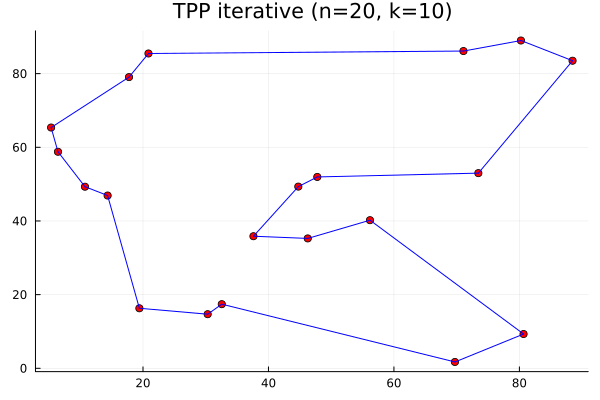

In [13]:
y_val = JuMP.value.(model_iter[:y])
println("Decyzje zakupów:")
for item in 1:size(cost_d, 1)
    city = argmax(y_val[item, :])
    price = cost_d[item, city]
    println("  Przedmiot $item -> miasto $city (cena $(round(price, digits=2)))")
end

plot_tpp_tour(X_d, Y_d, JuMP.value.(model_iter[:x]); title="TPP iterative (n=$n_demo, k=$k_demo)")

## Algorytm genetyczny dla TPP

Chromosom pozostaje permutacją w reprezentacji "next-city" (perm[i] = miasto odwiedzane bezpośrednio po mieście i). Ponieważ trasa odwiedza wszystkie miasta, optymalna decyzja zakupowa dla każdego przedmiotu (bez wagi) to po prostu miasto z najniższą ceną — można ją wyznaczyć analitycznie. Funkcja kosztu = długość trasy + suma minimalnych cen przedmiotów + kara, jeśli permutacja zawiera podtrasę.

In [ ]:
import Pkg

let
    pkg_id = Base.find_package("Evolutionary")
    if pkg_id === nothing
        Pkg.add(Pkg.PackageSpec(name="Evolutionary", version="0.11"))
    else
        info = Pkg.dependencies()
        for (uuid, dep) in info
            if dep.name == "Evolutionary"
                if dep.version === nothing || dep.version < v"0.11"
                    Pkg.add(Pkg.PackageSpec(name="Evolutionary", version="0.11"))
                end
                break
            end
        end
    end
end

using Evolutionary
using Random
using Printf

function perm_to_inv(perm::Vector)
    N = length(perm)
    inv = zeros(Int, N)
    for i in 1:N
        m = 1
        while perm[m] != i
            if perm[m] > i
                inv[i] += 1
            end
            m += 1
        end
    end
    return inv
end

function inv_to_perm(inv::Vector)
    N = length(inv)
    pos = zeros(Int, N)
    for i in N:-1:1
        for m in (i+1):N
            if pos[m] >= inv[i] + 1
                pos[m] += 1
            end
        end
        pos[i] = inv[i] + 1
    end
    perm = zeros(Int, N)
    for i in 1:N
        perm[pos[i]] = i
    end
    return perm
end

function has_subtour(perm::Vector)
    c = 1
    for _ in 1:(length(perm)-1)
        c = perm[c]
        if c == 1
            return true
        end
    end
    return false
end

function mutate_swap(recombinant::AbstractVector;
        rng::AbstractRNG=Random.default_rng())
    N = length(recombinant)
    a = true
    while a || has_subtour(recombinant)
        i = rand(rng, 1:N)
        j = rand(rng, 1:N)
        v = recombinant[i]
        recombinant[i] = recombinant[j]
        recombinant[j] = v
        a = false
    end
    return recombinant
end

# Krzyżowanie oparte o inwersje permutacji (jak w tsp-genetic.ipynb)
function recombine_inv(v1::T, v2::T;
        rng::AbstractRNG=Random.default_rng()) where {T <: AbstractVector}
    N = length(v1)
    i1 = perm_to_inv(v1)
    i2 = perm_to_inv(v2)
    cp = rand(rng, 2:(N-1))
    i1c = vcat(i1[1:cp], i2[(cp+1):N])
    i2c = vcat(i2[1:cp], i1[(cp+1):N])
    return inv_to_perm(i1c), inv_to_perm(i2c)
end

recombine_inv (generic function with 1 method)

In [6]:
function tour_order(perm::Vector)
    n = length(perm)
    order = zeros(Int, n)
    order[1] = 1
    for i in 2:n
        order[i] = perm[order[i-1]]
    end
    return order
end

function make_cost_tpp(d, cost_item_city)
    n = size(d, 1)
    k = size(cost_item_city, 1)
    purchase_baseline = 0.0
    for i in 1:k
        purchase_baseline += minimum(@view cost_item_city[i, :])
    end
    function cost(perm::Vector)
        travel = 0.0
        for i in 1:n
            travel += d[i, perm[i]]
        end
        if has_subtour(perm)
            return travel + purchase_baseline + 50000.0
        end
        return travel + purchase_baseline
    end
    return cost
end

function plot_ga_tour(X, Y, perm::Vector; title="")
    plt = Plots.plot(; title=title)
    Plots.scatter!(plt, X, Y; legend=false, color=:red)
    for i in 1:length(perm)
        j = perm[i]
        Plots.plot!(plt, [X[i], X[j]], [Y[i], Y[j]]; legend=false, color=:blue)
    end
    return plt
end

# Konwersja rozwiązania JuMP (macierz x) na permutację next-city
function jump_to_perm(x_val::AbstractMatrix)
    n = size(x_val, 1)
    perm = zeros(Int, n)
    visited = falses(n)
    visited[1] = true
    current = 1
    for _ in 1:(n-1)
        next_city = 0
        for j in 1:n
            if x_val[current, j] > 0.5 && !visited[j]
                next_city = j
                break
            end
        end
        @assert next_city != 0
        perm[current] = next_city
        visited[next_city] = true
        current = next_city
    end
    perm[current] = 1
    return perm
end

jump_to_perm (generic function with 1 method)

Koszt początkowy: 1506.426
Koszt GA: 1036.19
Czas GA: 0.611 s
Podtrasa? false


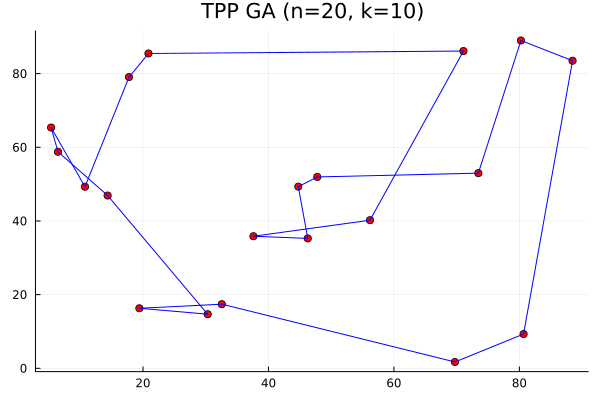

In [7]:
x0_demo = [mod1(i+1, n_demo) for i in 1:n_demo]
cost_fn_demo = make_cost_tpp(d_d, cost_d)
println("Koszt początkowy: $(round(cost_fn_demo(x0_demo), digits=3))")

ga_demo = GA(; populationSize=500, crossover=recombine_inv,
             mutation=mutate_swap, epsilon=0.05, crossoverRate=0.9)
opts_demo = Evolutionary.Options(; iterations=500, time_limit=30.0)

t_ga_demo = @elapsed (res_ga_demo = Evolutionary.optimize(cost_fn_demo, x0_demo, ga_demo, opts_demo))
println("Koszt GA: $(round(res_ga_demo.minimum, digits=3))")
println("Czas GA: $(round(t_ga_demo, digits=3)) s")
println("Podtrasa? $(has_subtour(res_ga_demo.minimizer))")

plot_ga_tour(X_d, Y_d, res_ga_demo.minimizer; title="TPP GA (n=$n_demo, k=$k_demo)")

## Porównanie 9 losowych problemów

Po trzy problemy dla każdego rozmiaru (n=50, k=20), (n=50, k=50) oraz (n=100, k=100).

In [8]:
function ga_params_for(n)
    if n <= 50
        return GA(; populationSize=500, crossover=recombine_inv,
                  mutation=mutate_swap, epsilon=0.05, crossoverRate=0.9),
               Evolutionary.Options(; iterations=2000, time_limit=55.0)
    else
        return GA(; populationSize=300, crossover=recombine_inv,
                  mutation=mutate_swap, epsilon=0.05, crossoverRate=0.9),
               Evolutionary.Options(; iterations=2000, time_limit=55.0)
    end
end

problems_30 = [(50, 20, 1), (50, 20, 2), (50, 20, 3),
               (50, 50, 4), (50, 50, 5), (50, 50, 6),
               (100, 100, 7), (100, 100, 8), (100, 100, 9)]

results_30 = Any[]
for (np, kp, seed) in problems_30
    println("Problem n=$np k=$kp seed=$seed")
    Xp, Yp, dp, cp = generate_random_tpp(np, kp; random_seed=seed)

    model_p, t_jump = solve_tpp_iterative(dp, cp)
    cost_jump = objective_value(model_p)

    cost_fn_p = make_cost_tpp(dp, cp)
    x0_p = [mod1(i+1, np) for i in 1:np]
    ga_p, opts_p = ga_params_for(np)
    t_ga = @elapsed (res_ga = Evolutionary.optimize(cost_fn_p, x0_p, ga_p, opts_p))
    cost_ga = res_ga.minimum

    push!(results_30, (n=np, k=kp, seed=seed,
        jump_cost=cost_jump, jump_time=t_jump,
        ga_cost=cost_ga, ga_time=t_ga))
    @printf "  JuMP: koszt=%.2f czas=%.2fs    GA: koszt=%.2f czas=%.2fs\n" cost_jump t_jump cost_ga t_ga
end

println("\n=== Tabela porównawcza (3.0) ===")
@printf "%4s %4s %5s %12s %10s %12s %10s %8s\n" "n" "k" "seed" "JuMP koszt" "JuMP t[s]" "GA koszt" "GA t[s]" "GA/JuMP"
for r in results_30
    @printf "%4d %4d %5d %12.2f %10.2f %12.2f %10.2f %8.3f\n" r.n r.k r.seed r.jump_cost r.jump_time r.ga_cost r.ga_time (r.ga_cost / r.jump_cost)
end

Problem n=50 k=20 seed=1
  JuMP: koszt=1569.95 czas=0.02s    GA: koszt=3154.74 czas=0.03s
Problem n=50 k=20 seed=2
  JuMP: koszt=1612.07 czas=0.58s    GA: koszt=2207.28 czas=0.24s
Problem n=50 k=20 seed=3
  JuMP: koszt=1679.49 czas=0.07s    GA: koszt=2633.15 czas=0.15s
Problem n=50 k=50 seed=4
  JuMP: koszt=3239.97 czas=0.31s    GA: koszt=4278.43 czas=0.15s
Problem n=50 k=50 seed=5
  JuMP: koszt=3149.27 czas=2.90s    GA: koszt=3629.29 czas=0.31s
Problem n=50 k=50 seed=6
  JuMP: koszt=3190.33 czas=11.23s    GA: koszt=4481.38 czas=0.21s
Problem n=100 k=100 seed=7
  JuMP: koszt=5860.38 czas=1356.27s    GA: koszt=9186.54 czas=1.01s
Problem n=100 k=100 seed=8
  JuMP: koszt=5890.58 czas=52.25s    GA: koszt=8331.07 czas=2.09s
Problem n=100 k=100 seed=9
  JuMP: koszt=5899.56 czas=100.31s    GA: koszt=7941.00 czas=3.55s

=== Tabela porównawcza (3.0) ===
   n    k  seed   JuMP koszt  JuMP t[s]     GA koszt    GA t[s]  GA/JuMP
  50   20     1      1569.95       0.02      3154.74       0.03    2.0

## Na 4.0

## Wagi przedmiotów

Dodano do problemu wagę przedmiotów. Koszt rozwiązania powiększa się o `alpha * weight[i] * remaining_dist[i]`, gdzie `remaining_dist[i]` to długość trasy od miasta zakupu przedmiotu `i` do końca trasy (powrót do miasta startowego). Współczynnik `alpha` dobrano tak, aby dla przedmiotu o wadze średniej transport między najbardziej odległymi miastami stanowił ~1% średniej ceny:

`alpha = 0.01 * mean(cost_item_city) / (mean(weights) * maximum(d))`

Składnik wagowy uwzględniamy tylko w funkcji kosztu algorytmu genetycznego — model JuMP rozwiązuje wersję bez wag (używamy go jako baseline).

In [9]:
function generate_weights(k; random_seed=1)
    rng = Random.MersenneTwister(random_seed)
    return 0.5 .+ rand(rng, k)  # w ∈ [0.5, 1.5], średnia ≈ 1.0
end

function compute_alpha(d, cost_item_city, weights)
    avg_weight = sum(weights) / length(weights)
    max_distance = maximum(d)
    avg_price = sum(cost_item_city) / length(cost_item_city)
    return 0.01 * avg_price / (avg_weight * max_distance)
end

function make_cost_tpp_weighted(d, cost_item_city, weights, alpha)
    n = size(d, 1)
    k = size(cost_item_city, 1)
    function cost(perm::Vector)
        travel = 0.0
        for i in 1:n
            travel += d[i, perm[i]]
        end
        if has_subtour(perm)
            return travel + 1e8
        end
        # Trasa zaczyna i kończy się w mieście 1
        order = zeros(Int, n)
        order[1] = 1
        for i in 2:n
            order[i] = perm[order[i-1]]
        end
        position = zeros(Int, n)
        for i in 1:n
            position[order[i]] = i
        end
        # remaining_dist[p] = suma długości krawędzi od pozycji p do końca trasy (pozycji n)
        remaining_dist = zeros(n)
        for p in (n-1):-1:1
            remaining_dist[p] = remaining_dist[p+1] + d[order[p], order[p+1]]
        end
        purchase = 0.0
        for item in 1:k
            best = Inf
            for c in 1:n
                tot = cost_item_city[item, c] + alpha * weights[item] * remaining_dist[position[c]]
                if tot < best
                    best = tot
                end
            end
            purchase += best
        end
        return travel + purchase
    end
    return cost
end

make_cost_tpp_weighted (generic function with 1 method)

In [10]:
println("=== Porównanie GA z wagą i bez (oraz JuMP bez wagi) ===")
results_weights = Any[]
for (np, kp, seed) in [(50, 20, 11), (50, 50, 12), (100, 100, 13)]
    Xp, Yp, dp, cp = generate_random_tpp(np, kp; random_seed=seed)
    weights = generate_weights(kp; random_seed=seed)
    alpha = compute_alpha(dp, cp, weights)
    println("\nProblem n=$np k=$kp seed=$seed alpha=$(round(alpha, sigdigits=4))")

    # JuMP (bez wagi)
    model_p, t_jump = solve_tpp_iterative(dp, cp)
    perm_jump = jump_to_perm(JuMP.value.(model_p[:x]))

    # GA bez wagi
    cost_unw = make_cost_tpp(dp, cp)
    x0_p = [mod1(i+1, np) for i in 1:np]
    ga_p, opts_p = ga_params_for(np)
    t_ga_unw = @elapsed (res_ga_unw = Evolutionary.optimize(cost_unw, x0_p, ga_p, opts_p))

    # GA z wagą
    cost_w = make_cost_tpp_weighted(dp, cp, weights, alpha)
    t_ga_w = @elapsed (res_ga_w = Evolutionary.optimize(cost_w, x0_p, ga_p, opts_p))

    # Ewaluacja każdego rozwiązania pod oboma kryteriami
    j_unw = cost_unw(perm_jump)
    j_w   = cost_w(perm_jump)
    gu_unw = cost_unw(res_ga_unw.minimizer)
    gu_w   = cost_w(res_ga_unw.minimizer)
    gw_unw = cost_unw(res_ga_w.minimizer)
    gw_w   = cost_w(res_ga_w.minimizer)

    push!(results_weights, (n=np, k=kp,
        j_unw=j_unw, j_w=j_w,
        gu_unw=gu_unw, gu_w=gu_w,
        gw_unw=gw_unw, gw_w=gw_w,
        t_jump=t_jump, t_ga_unw=t_ga_unw, t_ga_w=t_ga_w))

    @printf "  JuMP (bez wag):    bez_wag=%.2f  z_wag=%.2f\n" j_unw j_w
    @printf "  GA (bez wag):      bez_wag=%.2f  z_wag=%.2f\n" gu_unw gu_w
    @printf "  GA (z wagami):     bez_wag=%.2f  z_wag=%.2f\n" gw_unw gw_w
end

println("\n=== Tabela (4.0 — wagi) ===")
@printf "%4s %4s | %10s %10s | %10s %10s | %10s %10s\n" "n" "k" "JuMP bw" "JuMP zw" "GAbw bw" "GAbw zw" "GAzw bw" "GAzw zw"
for r in results_weights
    @printf "%4d %4d | %10.2f %10.2f | %10.2f %10.2f | %10.2f %10.2f\n" r.n r.k r.j_unw r.j_w r.gu_unw r.gu_w r.gw_unw r.gw_w
end
println("bw = funkcja celu bez wag, zw = z wagami; GAbw = GA optymalizujące bez wag, GAzw = GA z wagami.")

=== Porównanie GA z wagą i bez (oraz JuMP bez wagi) ===

Problem n=50 k=20 seed=11 alpha=0.007604
  JuMP (bez wag):    bez_wag=1652.60  z_wag=1689.38
  GA (bez wag):      bez_wag=2356.79  z_wag=2420.48
  GA (z wagami):     bez_wag=2191.31  z_wag=2269.56

Problem n=50 k=50 seed=12 alpha=0.007682
  JuMP (bez wag):    bez_wag=3171.81  z_wag=3248.77
  GA (bez wag):      bez_wag=3952.47  z_wag=4139.91
  GA (z wagami):     bez_wag=4018.17  z_wag=4176.17

Problem n=100 k=100 seed=13 alpha=0.007508
  JuMP (bez wag):    bez_wag=5862.24  z_wag=6061.96
  GA (bez wag):      bez_wag=8137.25  z_wag=8582.18
  GA (z wagami):     bez_wag=8952.43  z_wag=9426.77

=== Tabela (4.0 — wagi) ===
   n    k |    JuMP bw    JuMP zw |    GAbw bw    GAbw zw |    GAzw bw    GAzw zw
  50   20 |    1652.60    1689.38 |    2356.79    2420.48 |    2191.31    2269.56
  50   50 |    3171.81    3248.77 |    3952.47    4139.91 |    4018.17    4176.17
 100  100 |    5862.24    6061.96 |    8137.25    8582.18 |    8952.43   

## Krzyżowanie PMX

PMX stosujemy bezpośrednio na permutacji next-city — wynik pozostaje permutacją zbioru `{1..n}`, choć może zawierać podtrasy (są karane przez funkcję kosztu, jak w przypadku krzyżowania przez inwersję).

In [11]:
function pmx_crossover(p1::AbstractVector, p2::AbstractVector, cx1::Int, cx2::Int)
    n = length(p1)
    child = zeros(Int, n)
    @inbounds for q in cx1:cx2
        child[q] = p1[q]
    end
    seg1 = Set(@view p1[cx1:cx2])
    @inbounds for i in cx1:cx2
        v = p2[i]
        if !(v in seg1)
            j = i
            while child[j] != 0
                w = child[j]
                jnew = 0
                for q in 1:n
                    if p2[q] == w
                        jnew = q
                        break
                    end
                end
                j = jnew
            end
            child[j] = v
        end
    end
    @inbounds for i in 1:n
        if child[i] == 0
            child[i] = p2[i]
        end
    end
    return child
end

function recombine_pmx(v1::T, v2::T;
        rng::AbstractRNG=Random.default_rng()) where {T <: AbstractVector}
    N = length(v1)
    a, b = rand(rng, 1:N), rand(rng, 1:N)
    cx1, cx2 = min(a, b), max(a, b)
    if cx1 == cx2
        return copy(v1), copy(v2)
    end
    return pmx_crossover(v1, v2, cx1, cx2), pmx_crossover(v2, v1, cx1, cx2)
end

# sanity check
let
    p1 = [3, 4, 8, 2, 7, 1, 6, 5]
    p2 = [4, 2, 5, 1, 6, 8, 3, 7]
    c1 = pmx_crossover(p1, p2, 4, 6)
    c2 = pmx_crossover(p2, p1, 4, 6)
    @assert sort(c1) == 1:8
    @assert sort(c2) == 1:8
    println("PMX dzieci: ", c1, " ", c2)
end

PMX dzieci: [4, 8, 5, 2, 7, 1, 3, 6] [3, 4, 2, 1, 6, 8, 7, 5]


In [12]:
println("=== Porównanie PMX vs inwersja ===")
results_pmx = Any[]
for (np, kp, seed) in [(50, 20, 21), (50, 50, 22), (100, 100, 23)]
    Xp, Yp, dp, cp = generate_random_tpp(np, kp; random_seed=seed)
    cost_fn_p = make_cost_tpp(dp, cp)
    x0_p = [mod1(i+1, np) for i in 1:np]
    pop = (np <= 50 ? 500 : 300)
    opts = Evolutionary.Options(; iterations=2000, time_limit=55.0)

    ga_inv = GA(; populationSize=pop, crossover=recombine_inv,
                mutation=mutate_swap, epsilon=0.05, crossoverRate=0.9)
    t_inv = @elapsed (res_inv = Evolutionary.optimize(cost_fn_p, x0_p, ga_inv, opts))

    ga_pmx = GA(; populationSize=pop, crossover=recombine_pmx,
                mutation=mutate_swap, epsilon=0.05, crossoverRate=0.9)
    t_pmx = @elapsed (res_pmx = Evolutionary.optimize(cost_fn_p, x0_p, ga_pmx, opts))

    push!(results_pmx, (n=np, k=kp, seed=seed,
        inv_cost=res_inv.minimum, inv_time=t_inv,
        pmx_cost=res_pmx.minimum, pmx_time=t_pmx))

    @printf "n=%d k=%d  INV: koszt=%.2f t=%.2fs   PMX: koszt=%.2f t=%.2fs\n" np kp res_inv.minimum t_inv res_pmx.minimum t_pmx
end

println("\n=== Tabela (4.0 — PMX vs INV) ===")
@printf "%4s %4s %5s | %12s %10s | %12s %10s | %8s\n" "n" "k" "seed" "INV koszt" "INV t[s]" "PMX koszt" "PMX t[s]" "PMX/INV"
for r in results_pmx
    @printf "%4d %4d %5d | %12.2f %10.2f | %12.2f %10.2f | %8.3f\n" r.n r.k r.seed r.inv_cost r.inv_time r.pmx_cost r.pmx_time (r.pmx_cost / r.inv_cost)
end

=== Porównanie PMX vs inwersja ===
n=50 k=20  INV: koszt=2757.16 t=0.18s   PMX: koszt=1943.81 t=0.26s
n=50 k=50  INV: koszt=4297.82 t=0.08s   PMX: koszt=4417.31 t=0.02s
n=100 k=100  INV: koszt=9025.59 t=0.38s   PMX: koszt=6936.65 t=0.25s

=== Tabela (4.0 — PMX vs INV) ===
   n    k  seed |    INV koszt   INV t[s] |    PMX koszt   PMX t[s] |  PMX/INV
  50   20    21 |      2757.16       0.18 |      1943.81       0.26 |    0.705
  50   50    22 |      4297.82       0.08 |      4417.31       0.02 |    1.028
 100  100    23 |      9025.59       0.38 |      6936.65       0.25 |    0.769
